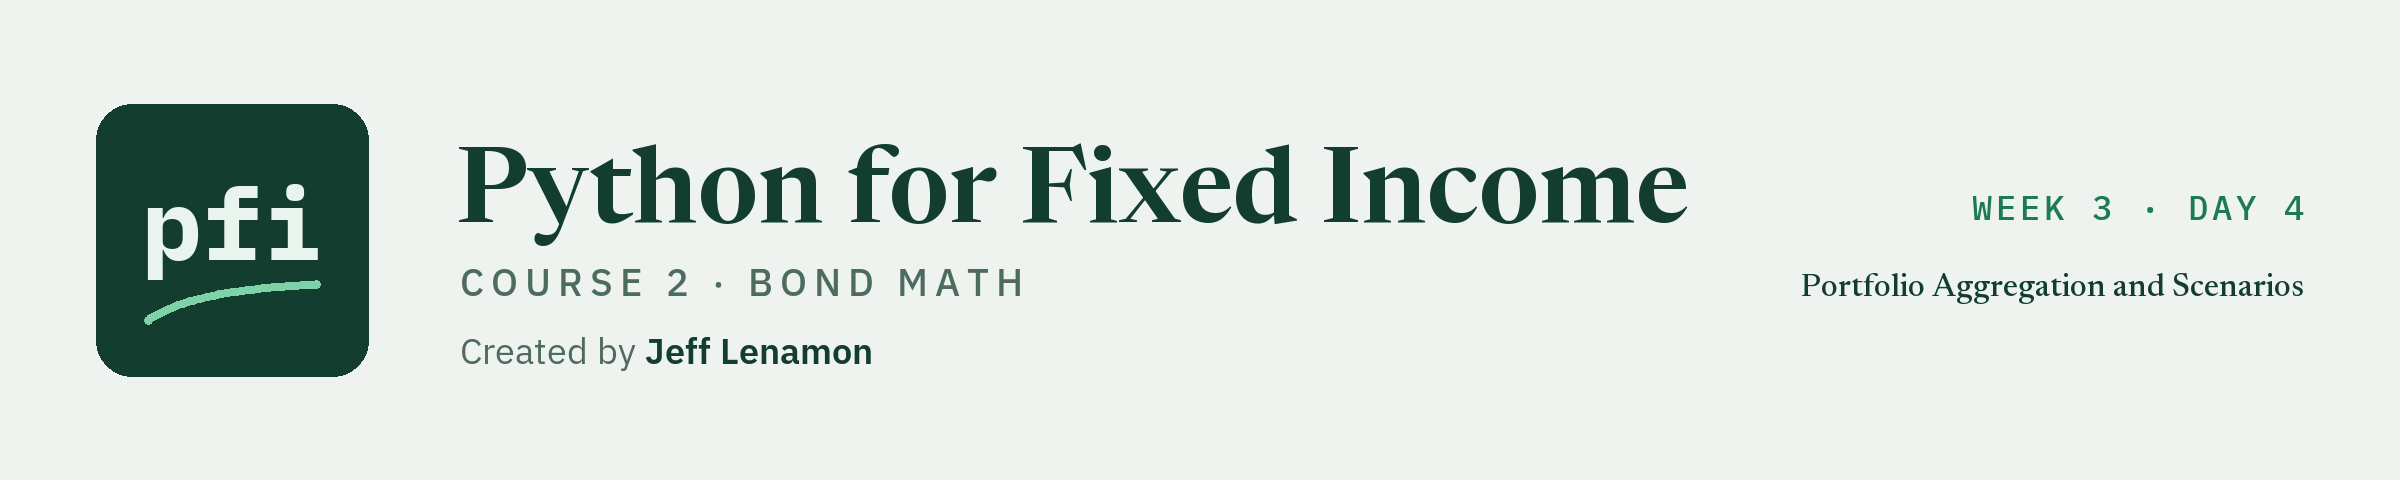

# Portfolio Aggregation and Scenarios

Week 3, Day 4. Roll the September book up from 200 bonds to one set of numbers: market value, weights, book duration, spread, DTS, and dollar DV01, by sector and rating, then reprice the whole book under rate and spread scenarios and write the grid to a workbook.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day4/14_portfolio_aggregation_and_scenarios.ipynb)

Days 7 to 13 gave every bond in `holdings.csv` its accrued interest, dirty price, duration, DV01, convexity, spread, spread duration, and DTS, one bond at a time. A risk report does not speak one bond at a time. It speaks for the **book**: what the 200 positions are worth together, and what that total does when yields or spreads move.

Today you have the September book, as of 30 September 2026, and five questions:

1. What is the book worth, and what share of it is each position?
2. What are the book's duration, spread, DTS, and DV01?
3. How do those split by sector and by rating bucket?
4. What would the book be worth if every yield moved by a set number of basis points, or every spread widened?
5. How close does duration plus convexity come to a full reprice of all 200 bonds?

Then the answers go into a workbook for Excel.

Today you will:

1. Compute market value from par and the dirty price, and tie it to the file to the cent.
2. Add `weighted_average` to your module, Excel's `SUMPRODUCT` over `SUM`.
3. Compute the book's duration, spread, DTS, convexity, and dollar DV01.
4. Split them by sector and by rating bucket, as a pivot table would.
5. Reprice the book under four parallel rate scenarios.
6. Reprice it under two spread scenarios.
7. Add `price_change_estimate`, and compare it with the full reprice.
8. Write the scenario grid to a workbook with `pd.ExcelWriter`, and read it back.

The issuers and the book are invented. Every scenario today is a mechanical what-if about this synthetic book: nothing here says what rates or spreads will do, or what anyone should hold.

The setup cell is the same as every day. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 13.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_14_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_14_frcnjl6u, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])


def test_years_to_maturity_cases():
    # (settlement, maturity, 30/360 days); each was checked in Excel as YEARFRAC(settlement, maturity, 0) x 360
    cases = [
        (date(2026, 9, 30), date(2036, 9, 30), 3600),  # exactly ten years
        (date(2026, 9, 30), date(2032, 6, 18), 2058),  # the first bond in holdings.csv
        (date(2027, 2, 28), date(2031, 8, 31), 1621),  # the 31st end stays 31 after a 28 February start
    ]
    for settlement, maturity, days in cases:
        assert bondmath.years_to_maturity(settlement, maturity) == pytest.approx(days / 360, abs=1e-12)


def test_spread_to_curve_known_case():
    # a 5 percent yield at 6 years: halfway between the 5-year (4.086) and 7-year (4.214) points
    curve_at_6_years = 4.086 + (4.214 - 4.086) * (6 - 5) / (7 - 5)
    expected_bp = (5.0 - curve_at_6_years) * 100
    result = bondmath.spread_to_curve_bp(5.0, 6.0, CURVE_TENORS, CURVE_YIELDS_PCT)
    assert result == pytest.approx(expected_bp, abs=1e-9)


def test_spread_reproduces_oas_rows():
    # five rows of holdings.csv (as of 2026-09-30): cusip, maturity, yield_pct, oas
    rows = [
        ("99080CAE8", date(2032, 6, 18), 5.606, 147),
        ("99049XAE2", date(2029, 4, 17), 9.22, 535),
        ("99039NAC0", date(2030, 6, 3), 5.509, 153),
        ("99039NAG1", date(2053, 4, 9), 6.756, 218),
        ("99034IAD4", date(2036, 4, 5), 5.6, 127),
    ]
    for cusip, maturity, yield_pct, oas in rows:
        years = bondmath.years_to_maturity(date(2026, 9, 30), maturity)
        # the file was built on the curve's formula at the bond's own maturity, rounded to 3 decimals,
        # so a one-point curve at exactly that maturity gives the file's spread
        curve_yield_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
        result = bondmath.spread_to_curve_bp(yield_pct, years, [years], [curve_yield_pct])
        assert result == pytest.approx(oas, abs=1e-9), cusip


def test_spread_duration_equals_modified_duration():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # for a bullet priced at curve plus spread, a spread move is a yield move; the 1 bp central
        # difference sits above the exact slope by up to 1.6e-5 years on a 30-year bond
        result = bondmath.spread_duration(*bond_inputs(row))
        assert result == pytest.approx(bondmath.modified_duration(*bond_inputs(row)), abs=5e-5), row["case_id"]


def test_dts_reproduces_file_rows():
    # five rows of holdings.csv: cusip, spread_duration, oas, dts (the file rounds dts to 1 decimal)
    rows = [
        ("99080CAE8", 4.627, 147, 680.2),
        ("99049XAE2", 2.165, 535, 1158.3),
        ("99039NAC0", 3.25, 153, 497.2),
        ("99039NAG1", 12.113, 218, 2640.6),
        ("99034IAD4", 7.338, 127, 931.9),
    ]
    for cusip, spread_duration_years, spread_bp, file_dts in rows:
        assert bondmath.dts(spread_duration_years, spread_bp) == pytest.approx(file_dts, abs=0.05 + 1e-9), cusip

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity', 'interpolate_yield', 'years_to_maturity', 'spread_to_curve_bp', 'spread_duration', 'dts']


* The two files exactly as day 13 left them: 23 functions and 37 tests. Today adds two functions and three tests.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_14_frcnjl6u and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 14: bondmath.py and test_bondmath.py as day 13 left them"
!git -C "{work}" log --oneline

dacc37b Start of day 14: bondmath.py and test_bondmath.py as day 13 left them


* One commit, the start of day 14. Its hash changes on every run.

Q. Read the September book and the rating scale.

In [8]:
# data_folder was fixed by the setup cell: the course repo's data folder, or GitHub in Colab
holdings = pd.read_csv(data_folder + "holdings.csv")
ratings = pd.read_csv(data_folder + "ratings.csv")

print(f"{len(holdings)} bonds, as of {holdings['as_of_date'].iloc[0]}")
holdings[["cusip", "issuer", "sector", "rating", "coupon", "maturity", "price", "accrued", "yield_pct", "oas",
          "par_held", "market_value"]].head()

200 bonds, as of 2026-09-30


,cusip,issuer,sector,rating,coupon,maturity,price,accrued,yield_pct,oas,par_held,market_value
0,99080CAE8,Bezane Finance,Financials,BBB-,7.000,2032-06-18,106.727,1.983,5.606,147,5000000,5435500.0
1,99049XAE2,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.556,3.679,9.220,535,250000,253087.5
2,99039NAC0,Bezoquil Freight,Transportation,BB,5.125,2030-06-03,98.730,1.666,5.509,153,1500000,1505940.0
3,99039NAG1,Bezoquil Freight,Transportation,BB,6.125,2053-04-09,92.261,2.909,6.756,218,500000,475850.0
4,99034IAD4,Bezorin Finance,Financials,BBB-,4.625,2036-04-05,92.883,2.248,5.600,127,2500000,2378275.0


* The same 200 bonds as days 10, 12, and 13. `price` is the clean quote and `accrued` the accrued interest, both per 100 of face. `par_held` is the face the book owns, in dollars, and `market_value` is what the file says that position is worth.

## 14.1 Market Value from Par and the Dirty Price

A buyer pays the dirty price: the clean quote plus the interest accrued since the last coupon (day 8). So a position is worth its face times the dirty price per 100. That is the course's convention, and the file's.

Q. Value the first position by hand.

In [9]:
first = holdings.iloc[0]

# the dirty price: the clean quote plus accrued interest, both per 100 of face
dirty = first["price"] + first["accrued"]
# market value in dollars: par held times the dirty price per 100 of face
market_value_dollars = first["par_held"] * dirty / 100

print(f"{first['issuer']}: clean {first['price']:.3f} + accrued {first['accrued']:.3f} = dirty {dirty:.3f}")
print(f"par {first['par_held']:,.0f} dollars x {dirty:.3f} / 100 = {market_value_dollars:,.2f} dollars")
print(f"the file's market_value: {first['market_value']:,.2f} dollars")

Bezane Finance: clean 106.727 + accrued 1.983 = dirty 108.710
par 5,000,000 dollars x 108.710 / 100 = 5,435,500.00 dollars
the file's market_value: 5,435,500.00 dollars


* Bezane Finance holds 5,000,000 dollars of face at a dirty price of 108.710, so the position is worth 5,435,500.00 dollars, exactly the file's number.

Q. Do the same for all 200 bonds, and check every one against the file to the cent.

In [10]:
holdings["dirty_price"] = holdings["price"] + holdings["accrued"]
holdings["market_value_check"] = holdings["par_held"] * holdings["dirty_price"] / 100

# to the cent: no position may be off by half a cent or more
largest_gap = (holdings["market_value_check"] - holdings["market_value"]).abs().max()
assert largest_gap < 0.005, "a market value does not tie to the file"

book_market_value = holdings["market_value"].sum()
print(f"largest gap to the file: {largest_gap:.2e} dollars")
print(f"book market value: {book_market_value:,.2f} dollars")

largest gap to the file: 9.31e-10 dollars
book market value: 490,819,215.00 dollars


* Every position ties. The largest gap is a rounding crumb of floating point, far below a cent. The book is worth **490,819,215.00 dollars**.

Q. What share of the book is each position? Weights are market value over the book's market value.

In [11]:
holdings["weight_pct"] = holdings["market_value"] / book_market_value * 100

print(f"weights add up to {holdings['weight_pct'].sum():.6f} percent")
holdings.sort_values("weight_pct", ascending=False)[["cusip", "issuer", "sector", "rating", "market_value", "weight_pct"]].head()

weights add up to 100.000000 percent


,cusip,issuer,sector,rating,market_value,weight_pct
0,99080CAE8,Bezane Finance,Financials,BBB-,5435500.0,1.107434
59,99021VAC2,Feskundra Systems,Technology,A+,5422700.0,1.104826
103,99076YAC0,Lorvebran Paper,Materials,BB,5287462.5,1.077273
194,99129ZAB6,Zarizal Industrial,Industrials,BB+,5253950.0,1.070445
104,99144OAF3,Lorvellix Energy,Energy,BBB+,5241650.0,1.067939


* The weights add up to 100. The largest position is Bezane Finance at 1.11 percent of the book; the five largest together are 5.43 percent. The book holds 20 different sizes of position, so a plain count of bonds would say little about where the money sits.
* Weights are on the dirty price. A weight on the clean price would leave the accrued interest out of every position, and the AI check at the end of the day is about exactly that.

**Excel side by side: market value.** Tested in Excel, with `holdings.csv` opened in Excel (the sheet is named `holdings`, and the columns are A to S in the file's order, so `par_held` is R, `price` I, `accrued` K, and `market_value` S). In an empty column, `=R2*(I2+K2)/100` filled down to row 201 gives each position's market value: 5,435,500.00 in the first row, and every row equals column S. For the book in one cell, `=SUMPRODUCT(R2:R201,I2:I201+K2:K201)/100` returns 490,819,215.00, the same as `=SUM(S2:S201)`. `SUMPRODUCT` multiplies the two ranges row by row and adds the products; `I2:I201+K2:K201` adds the two columns row by row first.

## 14.2 `weighted_average`

The book's duration is not the average of 200 durations. A 250,000-dollar position should count for less than a 5,000,000-dollar one. The book's number is the **market-value weighted average**: each bond's value times its market value, added up, divided by the total market value.

Q. Compute the book's duration by hand from the file's `duration` column, and compare it with the plain average.

In [12]:
# the sum of market value times duration, over the sum of market value
by_hand = (holdings["market_value"] * holdings["duration"]).sum() / holdings["market_value"].sum()
# every bond counted once, whatever its size
plain_mean = holdings["duration"].mean()

print(f"market-value weighted duration: {by_hand:.6f} years")
print(f"plain average of the durations: {plain_mean:.6f} years")

market-value weighted duration: 6.254777 years
plain average of the durations: 6.470405 years


* Weighted, 6.254777 years. The plain average says 6.470405: about 2.6 months longer, because in this book the larger positions have shorter durations, on average, than the smaller ones. The two answer different questions, and only the weighted one describes the money.

The same arithmetic will run for duration, spread, DTS, and convexity, for the book and for every sector and rating bucket. That is a function.

Q. Add `weighted_average` to the end of `bondmath.py`. Read it before you run the cell.

In [13]:
%%writefile -a bondmath.py


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight

Appending to bondmath.py


* The docstring states the units (the result has the units of the values), the convention, and the Excel formula, `SUMPRODUCT` over `SUM`.
* Two checks that stop: lists of different lengths, and weights that add up to zero, where the division would mean nothing.
* The loop is the sum of products written out. `zip` walks the two lists side by side.

Q. Reload the module and compute the book's duration with it.

In [14]:
importlib.reload(bondmath)

book_duration_file = bondmath.weighted_average(list(holdings["duration"]), list(holdings["market_value"]))
print(f"weighted_average: {book_duration_file:.6f} years")
print(f"by hand:          {by_hand:.6f} years")

weighted_average: 6.254777 years
by hand:          6.254777 years


* The same number. `list(...)` turns each column into a plain list, because the module takes plain numbers and has no pandas inside (the course's rule for `bondmath`).

Q. What does it do with weights that add up to zero?

In [15]:
try:
    bondmath.weighted_average([4.0, 6.0], [0, 0])
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: the weights sum to zero


* It refuses: `the weights sum to zero`. An empty sector or a filter that matched nothing would otherwise divide by zero, or worse, return a number.

**Excel side by side: `SUMPRODUCT` over `SUM`.** Tested in Excel on the same sheet. `=SUMPRODUCT(N2:N201,S2:S201)/SUM(S2:S201)` returns 6.254777, the weighted duration, and `=AVERAGE(N2:N201)` returns 6.470405, the plain one. The first argument of `SUMPRODUCT` here is the values and the second the weights, the order `weighted_average` takes them in. The same pattern gives the book spread, `=SUMPRODUCT(M2:M201,S2:S201)/SUM(S2:S201)`, which returns 180.4610 basis points, and the book DTS from the file's own column, `=SUMPRODUCT(P2:P201,S2:S201)/SUM(S2:S201)`, which returns 1064.1135.

Q. Add the first two tests.

In [16]:
%%writefile -a test_bondmath.py


def test_weighted_average_known_case():
    # (4 x 1 + 6 x 1 + 10 x 2) / (1 + 1 + 2) = 30 / 4
    assert bondmath.weighted_average([4.0, 6.0, 10.0], [1, 1, 2]) == pytest.approx(7.5, abs=1e-12)


def test_weighted_average_raises_on_zero_weights():
    with pytest.raises(ValueError):
        bondmath.weighted_average([4.0, 6.0], [0, 0])

Appending to test_bondmath.py


* A known case you can check by hand, worked in the comment, and the zero-weight check with `pytest.raises`.

## 14.3 Book Duration, Spread, DTS, and Dollar DV01

The file carries rounded duration, spread duration, and DTS columns. The course's rule is to recompute from first principles with the module, so the book numbers rest on functions you tested against Excel.

Q. Recompute every bond's dirty price, modified duration, convexity, DV01, spread duration, and DTS from its yield.

In [17]:
# bondmath takes datetime.date values
holdings["settlement"] = pd.to_datetime(holdings["as_of_date"]).dt.date
holdings["maturity_date"] = pd.to_datetime(holdings["maturity"]).dt.date

measures = []
for bond in holdings.itertuples():
    # the four arguments every pricing function takes first; frequency 2 and 30/360 are the defaults
    args = (bond.settlement, bond.maturity_date, bond.coupon, bond.yield_pct)
    spread_duration_years = bondmath.spread_duration(*args)
    measures.append({
        "dirty_from_yield": bondmath.dirty_price(*args),
        "modified_duration": bondmath.modified_duration(*args),
        "convexity": bondmath.convexity(*args),
        "dv01": bondmath.dv01(*args),
        "spread_duration_calc": spread_duration_years,
        "dts_calc": bondmath.dts(spread_duration_years, bond.oas),
    })

# the new columns, side by side with the file's
holdings = pd.concat([holdings, pd.DataFrame(measures)], axis=1)

# the file rounds duration to 3 decimals, so the recomputed value is within half of the last digit
duration_gap = (holdings["modified_duration"] - holdings["duration"]).abs().max()
assert duration_gap <= 0.0005 + 1e-9, "a duration does not reproduce the file"
print(f"largest gap to the file's duration: {duration_gap:.6f} years")
holdings[["cusip", "duration", "modified_duration", "dv01", "convexity", "oas", "dts", "dts_calc"]].head()

largest gap to the file's duration: 0.000498 years

,cusip,duration,modified_duration,dv01,convexity,oas,dts,dts_calc
0,99080CAE8,4.627,4.626971,0.050300,26.358006,147,680.2,680.164707
1,99049XAE2,2.165,2.164770,0.021915,6.130346,535,1158.3,1158.152110
2,99039NAC0,3.250,3.249883,0.032627,12.843846,153,497.2,497.232069
3,99039NAG1,12.113,12.112785,0.115277,232.886073,218,2640.6,2640.589069
4,99034IAD4,7.338,7.337905,0.069807,66.380211,127,931.9,931.914086


* Every duration reproduces the file's rounded column, as on day 10. `dts_calc` differs from the file's `dts` in the first decimal for some bonds, because the file multiplied its rounded spread duration by the spread (day 13).
* `pd.concat(..., axis=1)` puts the new columns beside the old ones, row by row.

Q. Roll the bonds up into the book's numbers.

In [18]:
weights = list(holdings["market_value"])

# market-value weighted averages, the Course 1 project's convention
book_duration = bondmath.weighted_average(list(holdings["modified_duration"]), weights)
book_spread = bondmath.weighted_average(list(holdings["oas"]), weights)
book_dts = bondmath.weighted_average(list(holdings["dts_calc"]), weights)
book_convexity = bondmath.weighted_average(list(holdings["convexity"]), weights)
# dollar DV01 adds up: each position's DV01 in dollars is par held x DV01 per 100 / 100
book_dv01 = (holdings["par_held"] * holdings["dv01"] / 100).sum()

print(f"Book market value: {book_market_value:,.2f} dollars")
print(f"Book duration:     {book_duration:.4f} years")
print(f"Book spread:       {book_spread:.2f} bp")
print(f"Book DTS:          {book_dts:.2f} years x bp")
print(f"Book convexity:    {book_convexity:.4f} years squared")
print(f"Book DV01:         {book_dv01:,.2f} dollars per bp")

Book market value: 490,819,215.00 dollars
Book duration:     6.2548 years
Book spread:       180.46 bp
Book DTS:          1064.11 years x bp
Book convexity:    66.9912 years squared
Book DV01:         306,996.11 dollars per bp


* The book: 490,819,215.00 dollars, a duration of 6.2548 years, a spread of 180.46 bp, DTS of 1064.11, and a DV01 of **306,996.11 dollars**: if every yield fell by one basis point, the book's market value would rise by about that much.
* The averages and the sum are different kinds of number. Duration, spread, DTS, and convexity are per unit of value, so they are averaged. DV01 in dollars is an amount, so it is added.

Q. Is the book DV01 the book's market value times its duration times one basis point?

In [19]:
from_duration = book_market_value * book_duration / 10000

print(f"sum of position DV01s:              {book_dv01:,.2f} dollars")
print(f"market value x duration x 0.0001:   {from_duration:,.2f} dollars")
print(f"gap: {book_dv01 - from_duration:,.2f} dollars")

sum of position DV01s:              306,996.11 dollars
market value x duration x 0.0001:   306,996.21 dollars
gap: -0.10 dollars


* Nearly. DV01 is modified duration times the dirty price times 0.0001, so the two agree but for 0.10 dollars. The gap comes from the prices: the DV01s use the dirty price recomputed from each yield, and the market values use the file's price, rounded to 3 decimals.

**Excel side by side: book DV01.** Tested in Excel: `=SUMPRODUCT(N2:N201,S2:S201)/10000` returns 306,996.49 dollars from the file's own `duration` and `market_value` columns, the same identity in one cell.

## 14.4 By Sector and by Rating Bucket

A risk report splits the book. The same measures, for each group of bonds: market value, weight, duration, spread, DTS, and DV01.

Q. Write one function that summarizes any group of bonds, and run it for every sector.

In [20]:
def summarize(bonds):
    """Book measures for a group of bonds: market-value weighted averages, and DV01 added up."""
    group_weights = list(bonds["market_value"])
    return {
        "bonds": len(bonds),
        "market_value": bonds["market_value"].sum(),
        "weight_pct": bonds["market_value"].sum() / book_market_value * 100,
        "duration": bondmath.weighted_average(list(bonds["modified_duration"]), group_weights),
        "spread_bp": bondmath.weighted_average(list(bonds["oas"]), group_weights),
        "dts": bondmath.weighted_average(list(bonds["dts_calc"]), group_weights),
        "dv01_dollars": (bonds["par_held"] * bonds["dv01"] / 100).sum(),
    }

# one row per sector: groupby hands each sector's rows to summarize
rows = {sector: summarize(group) for sector, group in holdings.groupby("sector")}
by_sector = pd.DataFrame.from_dict(rows, orient="index")

# each sector's share of the book's DTS: its weight times its DTS
by_sector["dts_contribution"] = by_sector["weight_pct"] / 100 * by_sector["dts"]
by_sector = by_sector.sort_values("market_value", ascending=False)

# the parts must add back to the book
assert abs(by_sector["market_value"].sum() - book_market_value) < 0.005
assert abs(by_sector["dv01_dollars"].sum() - book_dv01) < 1e-6
assert abs(by_sector["dts_contribution"].sum() - book_dts) < 1e-9
by_sector.round(3)

,bonds,market_value,weight_pct,duration,spread_bp,dts,dv01_dollars,dts_contribution
Materials,26,71701617.5,14.609,5.263,180.742,863.685,37739.112,126.172
Financials,26,68219672.5,13.899,6.220,176.083,1006.250,42434.631,139.860
Consumer,26,56629597.5,11.538,6.973,209.427,1395.781,39489.930,161.042
Telecom,21,55848270.0,11.379,6.157,166.875,1090.251,34384.377,124.055
Industrials,20,52540745.0,10.705,6.695,233.984,1567.198,35177.586,167.764
Transportation,20,48822897.5,9.947,8.187,120.946,914.169,39971.072,90.934
Health Care,20,38908187.5,7.927,5.125,128.033,637.251,19941.818,50.516
Energy,17,38830005.0,7.911,6.063,176.349,1025.166,23542.528,81.104
Technology,12,30311760.0,6.176,5.467,228.227,869.871,16572.549,53.721
Utilities,12,29006462.5,5.910,6.117,188.809,1166.574,17742.506,68.942


* Ten sectors. Materials is the largest by market value, 14.61 percent of the book; the largest contribution to the book's DTS comes from Industrials, 167.76 of the book's 1064.11.
* The asserts prove the split: market values and DV01s add back to the book, and so do the DTS contributions. A sector's DTS is an average, so the sector DTS figures themselves do not add up; their contributions, weight times DTS, do.
* This describes where the synthetic book's measures sit. It does not say a sector is good or bad to hold.

Q. The same by rating bucket, in rating order. `ratings.csv` maps each rating to its bucket.

In [21]:
# add each bond's bucket: BBB+, BBB, and BBB- are all bucket BBB
holdings = holdings.merge(ratings[["rating", "bucket"]], on="rating", how="left")
assert holdings["bucket"].notna().all(), "a rating is missing from ratings.csv"

# the buckets in the order of the rating scale, keeping only those the book holds
bucket_order = [b for b in ratings.drop_duplicates("bucket")["bucket"] if b in set(holdings["bucket"])]

rows = {bucket: summarize(group) for bucket, group in holdings.groupby("bucket")}
by_bucket = pd.DataFrame.from_dict(rows, orient="index").loc[bucket_order]
by_bucket["dts_contribution"] = by_bucket["weight_pct"] / 100 * by_bucket["dts"]
by_bucket.round(3)

,bonds,market_value,weight_pct,duration,spread_bp,dts,dv01_dollars,dts_contribution
AAA,2,8200605.0,1.671,5.706,20.954,116.723,4679.139,1.950
AA,8,13048305.0,2.658,4.140,34.090,150.513,5402.619,4.001
A,56,148505040.0,30.257,6.398,77.795,507.175,95015.044,153.454
BBB,62,151163415.0,30.798,7.255,129.215,965.123,109668.712,297.240
BB,49,113754240.0,23.176,5.585,219.521,1261.939,63536.721,292.472
B,18,43595535.0,8.882,5.298,485.791,2589.890,23095.540,230.039
CCC,5,12552075.0,2.557,4.460,854.180,3321.910,5598.336,84.954


* Spread rises down the rating scale, from 21.0 bp in AAA to 854.2 bp in CCC, and DTS rises with it, because DTS is spread duration times spread.
* The three high yield buckets, BB, B, and CCC, are 34.62 percent of the book's market value and 57.1 percent of its DTS. That is what DTS is for: it shows where the spread risk sits, which weight alone does not.

**Excel side by side: a pivot table by sector.** Tested in Excel on the opened `holdings` sheet. Add a helper column, `mv_x_duration`, with `=S2*N2` filled down (market value times duration). Select the data, Insert, PivotTable, and put `sector` in Rows and `market_value` in Values (Sum of market_value). Then add a calculated field (PivotTable Analyze, Fields, Items, & Sets, Calculated Field) named `book_duration` with the formula `=mv_x_duration/market_value`. A calculated field works on the sums, so for each sector it divides the sum of market value times duration by the sum of market value: the weighted average. Excel's pivot shows 71,701,617.50 and 5.263418 for Materials, and 6.254777 on the Grand Total row, the book duration from the file's column. The next cell computes the same from the file's `duration` column with `weighted_average`.

In [22]:
# what the pivot table shows: weighted durations from the file's own duration column, by sector
file_duration_by_sector = {sector: bondmath.weighted_average(list(group["duration"]), list(group["market_value"]))
                           for sector, group in holdings.groupby("sector")}
for sector, duration_years in file_duration_by_sector.items():
    print(f"{sector:<15} {duration_years:.6f} years")

Consumer        6.973329 years
Energy          6.062993 years
Financials      6.220267 years
Health Care     5.125511 years
Industrials     6.695374 years
Materials       5.263418 years
Technology      5.467375 years
Telecom         6.156766 years
Transportation  8.186803 years
Utilities       6.116694 years


* All ten agree with Excel's pivot table to the last printed digit. (They differ from the `duration` column of `by_sector` above in the fourth decimal or so, because that table uses the recomputed durations, not the file's rounded ones.)

## 14.5 Rate Scenarios: Parallel Shifts, Full Reprice

A scenario asks one question: **if every yield in the book moved by this much, right now, what would the book be worth?**

Every scenario today is a **mechanical what-if, not a forecast**. It moves yields and reprices; it says nothing about whether a move will happen, how likely it is, or what anyone should do about it. The rules are the course's conventions: the move is instantaneous, so settlement stays on 30 September 2026 and nothing accrues; there is no carry and no roll-down; and each bond is priced again in full with `dirty_price`, not estimated.

The book is repriced at its own yields first, so that every scenario's change is measured against the same arithmetic.

Q. What is the book worth when every bond is priced from its own yield?

In [23]:
base_value = (holdings["par_held"] * holdings["dirty_from_yield"] / 100).sum()

print(f"book value from the yields:      {base_value:,.2f} dollars")
print(f"book value from the file prices: {book_market_value:,.2f} dollars")
print(f"gap: {base_value - book_market_value:,.2f} dollars")

book value from the yields:      490,819,038.14 dollars
book value from the file prices: 490,819,215.00 dollars
gap: -176.86 dollars


* 490,819,038.14 dollars, 176.86 dollars below the file's total, because the file rounds each price to 3 decimals. Measuring each scenario from this base keeps that rounding out of every change.

Q. One bond first: Bezane Finance if its yield rose by 100 bp.

In [24]:
bond = holdings.iloc[0]

# dirty price at the bond's yield, and at the yield 100 bp higher: 100 bp is 1 percent
before = bondmath.dirty_price(bond["settlement"], bond["maturity_date"], bond["coupon"], bond["yield_pct"])
after = bondmath.dirty_price(bond["settlement"], bond["maturity_date"], bond["coupon"], bond["yield_pct"] + 100 / 100)
# the change in the position's value, in dollars
change_dollars = bond["par_held"] * (after - before) / 100

print(f"dirty price {before:.4f} at {bond['yield_pct']:.3f} percent, {after:.4f} at {bond['yield_pct'] + 1:.3f} percent")
print(f"change in the position: {change_dollars:,.2f} dollars")

dirty price 108.7099 at 5.606 percent, 103.8202 at 6.606 percent
change in the position: -244,484.16 dollars


* The dirty price falls from 108.7099 to 103.8202, and the 5,000,000-dollar position would lose 244,484.16 dollars.

Q. Write that as a function for the whole book, and run the four rate scenarios: every yield moved by -100, -25, +25, and +100 bp.

In [25]:
def reprice_pnl(new_yields_pct):
    """The change in each position's market value, in dollars, when every bond moves to its new yield."""
    after = [bondmath.dirty_price(s, m, c, y) for s, m, c, y in
             zip(holdings["settlement"], holdings["maturity_date"], holdings["coupon"], new_yields_pct)]
    # par x (dirty after - dirty before) / 100, one number per bond
    return holdings["par_held"] * (pd.Series(after, index=holdings.index) - holdings["dirty_from_yield"]) / 100

scenario_pnl = {}
for shift_bp in [-100, -25, 25, 100]:
    # a parallel shift: every yield moves by the same basis points
    scenario_pnl[f"rates {shift_bp:+d} bp"] = reprice_pnl(holdings["yield_pct"] + shift_bp / 100)

rate_table = pd.DataFrame({"pnl_dollars": {name: pnl.sum() for name, pnl in scenario_pnl.items()}})
rate_table["pnl_pct"] = rate_table["pnl_dollars"] / base_value * 100
rate_table.round(2)

,pnl_dollars,pnl_pct
rates -100 bp,32430983.84,6.61
rates -25 bp,7778969.05,1.58
rates +25 bp,-7573434.14,-1.54
rates +100 bp,-29134835.97,-5.94


* Down 100 bp, the book would gain 32,430,983.84 dollars; up 100 bp, it would lose 29,134,835.97. The gain is larger than the loss by 3,296,147.87 dollars. That is convexity (day 10): the price-yield curve bends, so prices rise more for a fall in yield than they fall for the same rise.
* `pnl_pct` is the change as a percent of the book. For a 100 bp move it sits close to the book's duration of 6.25 years, which is what duration promises.

Q. Does DV01 predict the 25 bp moves?

In [26]:
# a 25 bp move by DV01 alone: 25 times the dollars per basis point
by_dv01 = 25 * book_dv01
# the average size of the two full reprices, which cancels most of the convexity
average_25 = (rate_table.loc["rates -25 bp", "pnl_dollars"] - rate_table.loc["rates +25 bp", "pnl_dollars"]) / 2

print(f"25 x book DV01:                       {by_dv01:,.2f} dollars")
print(f"average of the two 25 bp reprices:    {average_25:,.2f} dollars")

25 x book DV01:                       7,674,902.76 dollars
average of the two 25 bp reprices:    7,676,201.59 dollars


* 7,674,902.76 against 7,676,201.59: DV01 is the slope at today's yields, so for a small move, averaged over up and down, it is very close. Section 14.7 makes the comparison properly.

**Excel side by side: a What-If Data Table over the book.** Tested in Excel on the opened `holdings` sheet. Type `shift_bp` in X1 and 0 in Y1: Y1 is the shift, in basis points. In V2 type `=PRICE(A2,H2,G2/100,(L2+$Y$1/100)/100,100,2,0)` and fill it down to row 201: each bond's clean price at its yield plus the shift (`A2` is the as-of date and `H2` the maturity, which Excel reads as dates when it opens the file). In W2, `=R2*(V2+K2)/100`, filled down: each position's market value at that price plus its accrued. In AA2, `=SUM(W2:W201)`: the book. Then put the shifts -100, -25, 0, 25, and 100 in Z3:Z7, select Z2:AA7, and choose Data, What-If Analysis, Data Table, with Column input cell Y1. Excel fills AA3:AA7 with `=TABLE(,Y1)`, the book's value at each shift. It showed 490,818,946.75 at 0 and 461,684,110.78 at +100: a change of -29,134,835.97 dollars, the same as the full reprice in Python to the cent, and the other three changes agree to the cent too. The value at 0 is 91.39 dollars below `base_value`, because column W adds the file's rounded `accrued` column where Python computes accrued from the dates; accrued does not move with the yield, so it cancels in every change.

## 14.6 Spread Scenarios: Every Spread Up 10 Percent, and Up 25 bp

Each yield in this book is the curve plus a spread (day 12). A spread scenario moves the spread and leaves the curve where it is. These are also **mechanical what-ifs, not forecasts**: they describe what the synthetic book would be worth if spreads were different at this instant, and nothing more.

Two shapes of spread move are common in risk reports:

* **Every spread up 25 bp**: the same basis points for every bond, whatever its spread.
* **Every spread up 10 percent**: each spread times 1.10, so a 50 bp spread moves 5 bp and a 1,000 bp spread moves 100 bp.

Day 13 showed that for a bullet priced at curve plus spread, a spread move is a yield move. So each scenario is a new set of yields, and `reprice_pnl` does the rest.

Q. Run both spread scenarios.

In [27]:
# up 10 percent: each yield rises by a tenth of its own spread; oas is in bp, so / 100 for percent
scenario_pnl["spreads +10 percent"] = reprice_pnl(holdings["yield_pct"] + 0.10 * holdings["oas"] / 100)
# up 25 bp: every yield rises by 25 bp
scenario_pnl["spreads +25 bp"] = reprice_pnl(holdings["yield_pct"] + 25 / 100)

for name in ["spreads +10 percent", "spreads +25 bp"]:
    total = scenario_pnl[name].sum()
    print(f"{name:<20} {total:,.2f} dollars, {total / base_value * 100:.4f} percent of the book")

# in this model, every spread up 25 bp moves every yield by 25 bp: the same as the +25 bp rate scenario
assert (scenario_pnl["spreads +25 bp"] - scenario_pnl["rates +25 bp"]).abs().max() == 0

spreads +10 percent  -5,150,093.57 dollars, -1.0493 percent of the book
spreads +25 bp       -7,573,434.14 dollars, -1.5430 percent of the book


* Every spread up 25 bp gives exactly the +25 bp rate scenario, bond by bond (the assert). With one curve and a spread added to it, a parallel move is a parallel move, whichever part of the yield it comes from. A real report keeps the two apart because real curves and spreads do not move as one; this synthetic book cannot show that difference.
* Every spread up 10 percent: -5,150,093.57 dollars, -1.0493 percent of the book. The book's spread is 180.5 bp, so the average move is about 18.0 bp, but the move is not spread evenly: the widest bonds move the most.

Q. DTS was built for this move. Does it predict it?

In [28]:
# a spread move of 10 percent of each spread: the percent price change is about -spread duration x 0.10 x spread,
# and spread duration x spread is DTS. DTS is in years x bp, so / 10000 for a decimal and x 100 for percent.
dts_estimate_pct = -0.10 * book_dts / 10000 * 100
full_pct = scenario_pnl["spreads +10 percent"].sum() / base_value * 100

print(f"from book DTS:  {dts_estimate_pct:.4f} percent")
print(f"full reprice:   {full_pct:.4f} percent")

from book DTS:  -1.0641 percent
full reprice:   -1.0493 percent


* -1.0641 percent from DTS against -1.0493 percent by full reprice. DTS times a relative spread change is a first-order estimate of the percent change in value, which is why DTS is the measure for spread moves that scale with the spread. The full reprice is a little smaller, from convexity again.

Q. Where does each spread scenario land, by rating bucket?

In [29]:
bucket_base = (holdings["par_held"] * holdings["dirty_from_yield"] / 100).groupby(holdings["bucket"]).sum()
spread_by_bucket = pd.DataFrame({
    "spreads_10_percent": scenario_pnl["spreads +10 percent"].groupby(holdings["bucket"]).sum(),
    "spreads_25_bp": scenario_pnl["spreads +25 bp"].groupby(holdings["bucket"]).sum(),
}).loc[bucket_order]
# each as a percent of the bucket's own value
spread_by_bucket["pct_10_percent"] = spread_by_bucket["spreads_10_percent"] / bucket_base * 100
spread_by_bucket["pct_25_bp"] = spread_by_bucket["spreads_25_bp"] / bucket_base * 100
spread_by_bucket.round(3)

,spreads_10_percent,spreads_25_bp,pct_10_percent,pct_25_bp
bucket,,,,
AAA,-9565.068,-115905.533,-0.117,-1.413
AA,-19609.533,-133828.477,-0.150,-1.026
A,-750009.388,-2345439.555,-0.505,-1.579
BBB,-1445935.329,-2700728.533,-0.957,-1.787
BB,-1417891.913,-1568178.584,-1.246,-1.379
B,-1100505.913,-570673.866,-2.524,-1.309
CCC,-406576.427,-138679.591,-3.239,-1.105


* Under +25 bp, each bucket's percent change follows its duration alone, because every bond moves the same 25 bp. Under +10 percent, it follows DTS: CCC bonds, with a spread of 854 bp, move about 85 bp, and lose 3.24 percent of their value; BBB bonds, at 129 bp, move about 13 bp and lose 0.96 percent.
* Same book, two shapes of spread move, two different pictures by bucket. The choice of scenario decides which part of the book a report lights up, so a report should always say which shape it used.

## 14.7 Full Reprice against `price_change_estimate`

Day 10 estimated a bond's price change from duration and convexity: dP / P = -D x dy + 0.5 x C x dy squared. Today that formula becomes a function, and the full reprices above become its test.

Q. Add `price_change_estimate` to the end of `bondmath.py`.

In [30]:
%%writefile -a bondmath.py


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Appending to bondmath.py


* The result is in price points per 100 of face, like a price, so it multiplies by the dirty price. `shift_bp` is in basis points and positive means yields up, so a long position's estimate is negative for a positive shift.

Q. Reload, and estimate Bezane Finance's +100 bp move.

In [31]:
importlib.reload(bondmath)

estimate = bondmath.price_change_estimate(before, bond["modified_duration"], bond["convexity"], 100)
duration_only = bondmath.price_change_estimate(before, bond["modified_duration"], 0.0, 100)

print(f"full reprice:              {after - before:.4f} per 100")
print(f"duration and convexity:    {estimate:.4f} per 100")
print(f"duration alone:            {duration_only:.4f} per 100")

full reprice:              -4.8897 per 100
duration and convexity:    -4.8867 per 100
duration alone:            -5.0300 per 100


* The full reprice moves -4.8897 points. Duration alone says -5.0300, too far down by 0.1403; adding convexity brings it to -4.8867, within 0.0030.

Q. Estimate all six scenarios for the whole book, and line them up against the full reprice.

In [32]:
def estimate_pnl(shifts_bp):
    """Duration-and-convexity estimate of each position's change in dollars, for each bond's shift in bp."""
    estimates = [bondmath.price_change_estimate(p, d, c, s) for p, d, c, s in
                 zip(holdings["dirty_from_yield"], holdings["modified_duration"], holdings["convexity"], shifts_bp)]
    return holdings["par_held"] * pd.Series(estimates, index=holdings.index) / 100

# each scenario's shift for every bond, in bp
scenario_shifts_bp = {name: pd.Series(float(name.split()[1]), index=holdings.index)
                      for name in scenario_pnl if name.startswith("rates")}
scenario_shifts_bp["spreads +10 percent"] = 0.10 * holdings["oas"]
scenario_shifts_bp["spreads +25 bp"] = pd.Series(25.0, index=holdings.index)

grid = pd.DataFrame({
    "scenario": list(scenario_pnl),
    "pnl_dollars": [pnl.sum() for pnl in scenario_pnl.values()],
    "estimate_dollars": [estimate_pnl(scenario_shifts_bp[name]).sum() for name in scenario_pnl],
})
grid["gap_dollars"] = grid["pnl_dollars"] - grid["estimate_dollars"]
grid["pnl_pct"] = grid["pnl_dollars"] / base_value * 100
grid.round(2)

,scenario,pnl_dollars,estimate_dollars,gap_dollars,pnl_pct
0,rates -100 bp,32430983.84,32343637.85,87345.99,6.61
1,rates -25 bp,7778969.05,7777654.44,1314.62,1.58
2,rates +25 bp,-7573434.14,-7572151.08,-1283.05,-1.54
3,rates +100 bp,-29134835.97,-29055584.23,-79251.74,-5.94
4,spreads +10 percent,-5150093.57,-5148828.79,-1264.78,-1.05
5,spreads +25 bp,-7573434.14,-7572151.08,-1283.05,-1.54


* For the 25 bp moves the estimate is within 1,315 dollars of the full reprice, on a change of about 7.8 million. For the 100 bp moves the gap grows to 87,346 and 79,252 dollars: the terms the formula leaves out grow faster than the move.
* `name.split()[1]` reads the shift out of the scenario's name: `"rates -100 bp".split()` is `["rates", "-100", "bp"]`.

Q. Chart the book's change against the shift, from -200 to +200 bp: the full reprice, duration alone, and duration plus convexity.

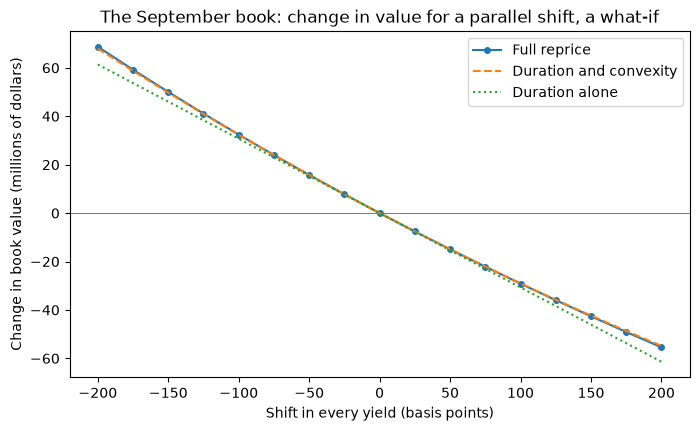

In [33]:
import matplotlib.pyplot as plt

shifts = list(range(-200, 201, 25))
full, with_convexity, duration_alone = [], [], []
for shift_bp in shifts:
    full.append(reprice_pnl(holdings["yield_pct"] + shift_bp / 100).sum() / 1e6)
    with_convexity.append(estimate_pnl([shift_bp] * len(holdings)).sum() / 1e6)
    # duration alone: the same function with the convexity set to zero
    alone = [bondmath.price_change_estimate(p, d, 0.0, shift_bp) for p, d in
             zip(holdings["dirty_from_yield"], holdings["modified_duration"])]
    duration_alone.append((holdings["par_held"] * pd.Series(alone, index=holdings.index) / 100).sum() / 1e6)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(shifts, full, marker="o", markersize=4, label="Full reprice")
ax.plot(shifts, with_convexity, linestyle="--", label="Duration and convexity")
ax.plot(shifts, duration_alone, linestyle=":", label="Duration alone")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("The September book: change in value for a parallel shift, a what-if")
ax.set_xlabel("Shift in every yield (basis points)")
ax.set_ylabel("Change in book value (millions of dollars)")
ax.legend()
plt.show()

* Duration alone is a straight line. The full reprice bends above it on both sides, and duration plus convexity follows the bend closely until the moves get large. A risk report that quotes a large scenario should quote the full reprice.

Q. Add the third test: the estimate against a full reprice for a 5 bp move, on every holdings row of the reference file.

In [34]:
%%writefile -a test_bondmath.py


def test_estimate_close_to_full_reprice_for_small_shift():
    shift_bp = 5
    for row in REFERENCE:
        if row["group"] != "holdings":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # full reprice: the dirty price after the shift minus the dirty price before
        before = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        after = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct + shift_bp / 100, frequency, basis)
        # the estimate from duration and convexity
        duration_years = bondmath.modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        convexity_years2 = bondmath.convexity(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
        estimate = bondmath.price_change_estimate(before, duration_years, convexity_years2, shift_bp)
        assert estimate == pytest.approx(after - before, abs=1e-4), row["case_id"]

Appending to test_bondmath.py


* The rows are Excel's reference rows for the 200 holdings bonds. A 5 bp move is small, so the estimate must be within 0.0001 per 100 of the full reprice for every one of them.

Q. Run the tests.

In [35]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................................                                 [100%]
40 passed in 1.56s



* `40 passed`: the 37 from days 1 to 13 and today's three.

## 14.8 The Scenario Grid in a Workbook

On day 5 you wrote a workbook of live formulas with openpyxl. Today's workbook holds results: the scenario grid, and the change by sector under each scenario, as numbers. pandas writes a DataFrame to a sheet with `to_excel`, and `pd.ExcelWriter` lets several DataFrames share one workbook, one sheet each.

Q. Finish the grid: the book's value before and after each scenario, then the change by sector.

In [36]:
grid.insert(1, "value_before_dollars", base_value)
grid.insert(2, "value_after_dollars", base_value + grid["pnl_dollars"])
grid = grid[["scenario", "value_before_dollars", "value_after_dollars", "pnl_dollars", "pnl_pct",
             "estimate_dollars", "gap_dollars"]]

# one column per scenario, one row per sector: the change in dollars
by_sector_scenarios = pd.DataFrame({name: pnl.groupby(holdings["sector"]).sum() for name, pnl in scenario_pnl.items()})
by_sector_scenarios.index.name = "sector"
by_sector_scenarios.round(2)

,rates -100 bp,rates -25 bp,rates +25 bp,rates +100 bp,spreads +10 percent,spreads +25 bp
sector,,,,,,
Consumer,4200725.04,1002309.69,-972605.39,-3724116.90,-774205.89,-972605.39
Energy,2468684.43,595499.91,-581763.40,-2248593.33,-393220.49,-581763.40
Financials,4447114.88,1073211.88,-1048762.69,-4055382.93,-677729.88,-1048762.69
Health Care,2099892.73,504899.01,-492350.61,-1898650.14,-245986.29,-492350.61
Industrials,3725279.77,891911.15,-867281.44,-3330324.83,-811052.73,-867281.44
Materials,3979271.22,955806.97,-931464.89,-3588835.46,-612778.81,-931464.89
Technology,1728095.58,418629.68,-410069.51,-1591008.69,-260276.32,-410069.51
Telecom,3624720.64,870792.79,-848712.48,-3270529.69,-601533.96,-848712.48
Transportation,4299886.13,1017302.78,-981808.64,-3730120.99,-442649.51,-981808.64


* Each column adds up to the book's change in that scenario: the sectors split it, nothing is lost.

Q. Write both tables to one workbook in the work folder.

In [37]:
# no folder in the name: the file goes into the work folder, never into the course repo
with pd.ExcelWriter("scenario_grid.xlsx") as writer:
    grid.to_excel(writer, sheet_name="scenarios", index=False)
    by_sector_scenarios.to_excel(writer, sheet_name="by_sector")

    # how Excel shows the numbers: dollars with thousands separators and cents, percents to 3 decimals
    for sheet in writer.sheets.values():
        for column in sheet.columns:
            sheet.column_dimensions[column[0].column_letter].width = 22
            for cell in column[1:]:
                if isinstance(cell.value, float):
                    cell.number_format = "0.000" if column[0].value == "pnl_pct" else "#,##0.00"
    sheet_names = list(writer.sheets)

print(f"Saved scenario_grid.xlsx in {work.name}, sheets: {sheet_names}")
print(f'To open it from PowerShell:  Invoke-Item "$env:TEMP\\{work.name}\\scenario_grid.xlsx"')

Saved scenario_grid.xlsx in pfi_course2_14_frcnjl6u, sheets: ['scenarios', 'by_sector']
To open it from PowerShell:  Invoke-Item "$env:TEMP\pfi_course2_14_frcnjl6u\scenario_grid.xlsx"


* `with pd.ExcelWriter(...) as writer:` opens the workbook, and the end of the `with` block saves and closes it. Each `to_excel` adds a sheet.
* `index=False` leaves out the grid's row numbers. The sector table keeps its index, the sector names, as its first column.
* `writer.sheets` holds the openpyxl sheets, so the formats are set with openpyxl, as on day 5: a width for every column, and a number format for every number below the header row.

Q. Read the workbook back with pandas and check it holds what was written.

In [38]:
back_grid = pd.read_excel("scenario_grid.xlsx", sheet_name="scenarios")
back_sectors = pd.read_excel("scenario_grid.xlsx", sheet_name="by_sector", index_col=0)

# the same scenarios and sectors, in the same order, and the same numbers
assert list(back_grid["scenario"]) == list(grid["scenario"])
assert list(back_sectors.index) == list(by_sector_scenarios.index)
number_columns = grid.columns[1:]
largest = max((back_grid[number_columns] - grid[number_columns]).abs().max().max(),
              (back_sectors - by_sector_scenarios).abs().max().max())
# far below a cent, or stop
assert largest < 1e-6, "a number changed on the way through the file"
print(f"largest difference after the round trip: {largest:.1e} dollars")
back_grid.round(2)

largest difference after the round trip: 3.7e-09 dollars


,scenario,value_before_dollars,value_after_dollars,pnl_dollars,pnl_pct,estimate_dollars,gap_dollars
0,rates -100 bp,4.908190e+08,5.232500e+08,32430983.84,6.61,32343637.85,87345.99
1,rates -25 bp,4.908190e+08,4.985980e+08,7778969.05,1.58,7777654.44,1314.62
2,rates +25 bp,4.908190e+08,4.832456e+08,-7573434.14,-1.54,-7572151.08,-1283.05
3,rates +100 bp,4.908190e+08,4.616842e+08,-29134835.97,-5.94,-29055584.23,-79251.74
4,spreads +10 percent,4.908190e+08,4.856689e+08,-5150093.57,-1.05,-5148828.79,-1264.78
5,spreads +25 bp,4.908190e+08,4.832456e+08,-7573434.14,-1.54,-7572151.08,-1283.05


* The names, the sectors, and every number come back, the numbers to within a few billionths of a dollar: the trip through the file can change the last of a long number's digits, far below anything a cent would notice. Unlike day 5's formulas, these cells hold values, so pandas has something to read.

**What Excel shows.** Tested in Excel: we opened exactly this workbook in desktop Excel. It has two sheets, `scenarios` and `by_sector`, in that order. The dollar columns show thousands separators and cents, for example -29,134,835.97 in the `pnl_dollars` column of the `rates +100 bp` row, and `pnl_pct` shows three decimals. Every number on both sheets showed the same figure as the tables above, rounded to the format, and no column was too narrow (no `####`). The cells hold the full numbers: click one and the formula bar shows every digit.

To see it yourself, run the PowerShell line the save cell printed, or open the file from the work folder in File Explorer.

## Excel Side by Side

Today's Excel, in one place, on `holdings.csv` opened in Excel. Every formula and step was tested in Excel. Column letters follow the file: E `sector`, I `price`, K `accrued`, M `oas`, N `duration`, P `dts`, R `par_held`, S `market_value`.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Market value of a row | `par_held * (price + accrued) / 100` | `=R2*(I2+K2)/100` | 5,435,500.00 |
| Book market value | `holdings["market_value"].sum()` | `=SUMPRODUCT(R2:R201,I2:I201+K2:K201)/100` | 490,819,215.00 |
| Book duration | `bondmath.weighted_average(durations, market_values)` | `=SUMPRODUCT(N2:N201,S2:S201)/SUM(S2:S201)` | 6.254777 |
| Plain average | `holdings["duration"].mean()` | `=AVERAGE(N2:N201)` | 6.470405 |
| Book spread | `weighted_average` of `oas` | `=SUMPRODUCT(M2:M201,S2:S201)/SUM(S2:S201)` | 180.4610 |
| Book DV01, dollars | sum of par x DV01 / 100 | `=SUMPRODUCT(N2:N201,S2:S201)/10000` | 306,996.49 |
| By sector | `groupby("sector")` and `summarize` | pivot table, `sector` in Rows, calculated field `=mv_x_duration/market_value` | 5.263418 for Materials |
| Rate scenarios | `reprice_pnl` | Data Table over `=SUM(W2:W201)`, column input Y1 | -29,134,835.97 at +100 bp |
| The workbook | `pd.ExcelWriter`, `to_excel` | open `scenario_grid.xlsx` | two sheets, formatted |

To try it: open `holdings.csv` from the course's `data` folder in Excel, type the `SUMPRODUCT` formulas in empty cells, and compare them with sections 14.1 to 14.3. Then build the Data Table of section 14.5 and watch the book's value change with the shift.

## Save the Day with Git

Today's Git step: **taking back a file you staged by mistake.** The work folder now holds a new file, the workbook.

Q. What has changed since the start of the day?

In [39]:
# the files that changed, and the files Git does not track
!git -C "{work}" status --short

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv
?? scenario_grid.xlsx


* ` M` beside both module files: 33 lines added to `bondmath.py` and 26 to `test_bondmath.py`.
* `??` beside the untracked files: the two reference CSVs, `__pycache__/`, and `scenario_grid.xlsx`.

Q. Stage today's work, and, by habit, the workbook too.

In [40]:
# a slip: the workbook is staged along with the two files
!git -C "{work}" add bondmath.py test_bondmath.py scenario_grid.xlsx
!git -C "{work}" status --short

M  bondmath.py
A  scenario_grid.xlsx
M  test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* `A ` beside `scenario_grid.xlsx`: it is staged, added to what the next commit will hold. It should not be. It is an output: the notebook makes it again on every run, and Git cannot show a readable diff of a binary file. The record should hold the code that makes it, not the file.

Q. Take it back out of the staging area, without touching the file.

In [41]:
# unstage the workbook: the file stays in the folder, untracked again
!git -C "{work}" restore --staged scenario_grid.xlsx
!git -C "{work}" status --short

M  bondmath.py


M  test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv
?? scenario_grid.xlsx


* `git restore --staged` moves a file out of the staging area and leaves the file itself alone. `scenario_grid.xlsx` is back to `??`, and the two module files are still staged (`M `).
* Without `--staged`, `git restore` would put a tracked file back to its last commit (day 4). With it, only the staging changes. Nothing is deleted.

Q. Commit today's work.

In [42]:
# commit what is staged, then the history and what the last commit holds
!git -C "{work}" commit -q -m "Add weighted_average and price_change_estimate, for the book and its scenarios" -m "Day 14 rolls the bonds up into a book and reprices it under rate and spread what-ifs."
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --oneline HEAD

c8d9114 Add weighted_average and price_change_estimate, for the book and its scenarios
dacc37b Start of day 14: bondmath.py and test_bondmath.py as day 13 left them


c8d9114 Add weighted_average and price_change_estimate, for the book and its scenarios
 bondmath.py      | 33 +++++++++++++++++++++++++++++++++
 test_bondmath.py | 26 ++++++++++++++++++++++++++
 2 files changed, 59 insertions(+)


* Two commits. `git show --stat` lists the two module files and nothing else: the workbook never entered the record.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the two `%%writefile -a bondmath.py` cells, in sections 14.2 and 14.7, in order, without their first lines. In `test_bondmath.py`, do the same with the two `%%writefile -a test_bondmath.py` cells, in sections 14.2 and 14.7. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
........................................                                 [100%]
40 passed in 1.20s
```

If you added the exercise functions of days 1 to 13 with their tests, you will see 53 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, stage it, check what is staged, and commit.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git status --short
git commit -m "Add weighted_average and price_change_estimate, for the book and its scenarios" -m "Day 14 rolls the bonds up into a book and reprices it under rate and spread what-ifs."
```

**If you stage a file by mistake**, for example with `git add .`, take it back out before you commit, and check:

```powershell
git restore --staged <file name>
git status --short
```

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads. Download `scenario_grid.xlsx` too if you want to open it in Excel.

## You Can Now

* Compute market value from par and the dirty price, and tie it to a file to the cent.
* Weight by market value with `weighted_average`, Excel's `SUMPRODUCT` over `SUM`, and say why a plain average misleads.
* Produce the book's duration, spread, DTS, convexity, and dollar DV01, and say which are averages and which add up.
* Split the book by sector and by rating bucket, with contributions that add back to the book, as a pivot table does.
* Reprice a whole book under parallel rate shifts and under two shapes of spread move, and say what each scenario is and is not.
* Compare a full reprice with `price_change_estimate`, and say when the estimate stops being enough.
* Write a scenario grid to a workbook with `pd.ExcelWriter`, read it back, and take a staged file back out with `git restore --staged`.

Tomorrow is the capstone. A November book arrives as a raw extract with bond-math problems planted in it. You will clean it, recompute every measure with your module, reconcile it to the operations team's control totals, and turn today's steps into one function that writes a risk report: positions, the summary by sector and rating bucket, and the scenarios, in a workbook of three sheets. Then you will run the same function on today's September book.

## Exercises

The exercises use twenty bonds from `benchmark.csv` that the September book does not hold, as of the same date, 30 September 2026. Treat them as a small book with 1,000,000 dollars of face in each bond. The issuers are invented, and every answer describes the data. The scenarios are what-ifs, as in the lesson.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It reads the twenty bonds, gives each 1,000,000 dollars of face, and defines `check`, a small function that marks your answers.

In [43]:
from datetime import date

benchmark = pd.read_csv(data_folder + "benchmark.csv")

# twenty bonds the September book does not hold
exercise_cusips = [
    "99001BAB2", "99008IAD6", "99016QAG1", "99025ZAD7", "99032GAB4", "99039NAF3", "99047VAF5", "99055DAB3",
    "99061JAC0", "99071TAA0", "99078AAA4", "99085HAD4", "99092OAB4", "99099VAB1", "99106CAA6", "99112IAH0",
    "99119PAB0", "99125VAD5", "99134EAB6", "99140KAC2",
]
exercise_book = benchmark[benchmark["cusip"].isin(exercise_cusips)].reset_index(drop=True)
# the same face in every bond, in dollars
exercise_book["par_held"] = 1_000_000
exercise_book["settlement"] = pd.to_datetime(exercise_book["as_of_date"]).dt.date
exercise_book["maturity_date"] = pd.to_datetime(exercise_book["maturity"]).dt.date


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_book[["cusip", "issuer", "sector", "rating", "coupon", "maturity", "price", "accrued", "yield_pct", "oas"]]

,cusip,issuer,sector,rating,coupon,maturity,price,accrued,yield_pct,oas
0,99001BAB2,Quorvane Energy,Energy,BBB,5.750,2035-08-08,101.558,0.831,5.524,122
1,99008IAD6,Osmere Chemicals,Materials,BBB-,5.250,2032-07-21,99.982,1.006,5.252,111
2,99016QAG1,Corvolvey Systems,Technology,BB+,6.000,2028-08-11,101.618,0.817,5.075,128
3,99025ZAD7,Kezazor Logistics,Transportation,A,3.375,2028-03-14,98.490,0.150,4.457,71
4,99032GAB4,Queloquil Health,Health Care,BBB-,6.375,2035-02-01,102.218,1.045,6.031,175
5,99039NAF3,Bezoquil Freight,Transportation,BB,4.875,2035-11-15,92.474,1.828,5.955,164
6,99047VAF5,Quelundra Power,Utilities,A,5.875,2037-11-24,104.993,2.056,5.276,89
7,99055DAB3,Mulvebran Logistics,Transportation,BB,5.875,2036-02-25,97.246,0.571,6.266,194
8,99061JAC0,Morvostrin Finance,Financials,BBB+,4.000,2038-03-05,87.976,0.278,5.425,103
9,99071TAA0,Corvoquil Metals,Materials,A-,4.625,2028-09-27,99.783,0.039,4.740,93


### Exercise 1

Q. Compute each position's market value from its face and the file's dirty price (`price` plus `accrued`). Store the book's market value in dollars in **ex1_market_value**. Then compute each bond's modified duration from its yield with `bondmath.modified_duration`, and store the market-value weighted duration of the book, from `bondmath.weighted_average`, in **ex1_duration**.

In [44]:
ex1_market_value = ...
ex1_duration = ...

In [45]:
check("Exercise 1 market value", ex1_market_value, 19891680.0)
check("Exercise 1 book duration", ex1_duration, 5.872304693449307)

Exercise 1 market value: not attempted yet
Exercise 1 book duration: not attempted yet


### Exercise 2

Q. Reprice the exercise book in full with `bondmath.dirty_price` for a parallel shift of -100 bp and of +100 bp. Measure each change from the dirty price at each bond's own yield, as in section 14.5. Store the book's change in dollars in **ex2_down_100** and **ex2_up_100**.

In [46]:
ex2_down_100 = ...
ex2_up_100 = ...

In [47]:
check("Exercise 2 down 100 bp", ex2_down_100, 1227014.845920279)
check("Exercise 2 up 100 bp", ex2_up_100, -1114103.8557471745)

Exercise 2 down 100 bp: not attempted yet
Exercise 2 up 100 bp: not attempted yet


### Exercise 3

Q. Reprice the exercise book with every spread up 10 percent (each yield up by a tenth of its own `oas`, in bp). Store the book's change in dollars in **ex3_spread_pnl**. Then compute each bond's DTS from `bondmath.spread_duration` and `bondmath.dts`, and store the book's market-value weighted DTS in **ex3_dts**.

In [48]:
ex3_spread_pnl = ...
ex3_dts = ...

In [49]:
check("Exercise 3 spreads up 10 percent", ex3_spread_pnl, -151874.70737842587)
check("Exercise 3 book DTS", ex3_dts, 768.3161885533202)

Exercise 3 spreads up 10 percent: not attempted yet
Exercise 3 book DTS: not attempted yet


### Exercise 4

Q. Add a function to your module. `scenario_pnl_dollars(par, dirty_price_before, dirty_price_after)` returns the change in a position's market value in dollars. Write the docstring first: units, convention, and the Excel formula. Then add a test, `test_scenario_pnl_dollars_known_case`, with a case you can check by hand. Run pytest, reload the module, and store the exercise book's change for a +25 bp parallel shift, added up from `bondmath.scenario_pnl_dollars` over the twenty bonds, in **ex4_up_25**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [50]:
%%writefile -a bondmath.py


# Exercise 4: write scenario_pnl_dollars(par, dirty_price_before, dirty_price_after) below this line

Appending to bondmath.py


In [51]:
%%writefile -a test_bondmath.py


# Exercise 4: write test_scenario_pnl_dollars_known_case() below this line

Appending to test_bondmath.py


In [52]:
# run pytest, reload the module, then add up your function over the twenty bonds
ex4_up_25 = ...

In [53]:
check("Exercise 4 up 25 bp", ex4_up_25, -288540.79312331806)

Exercise 4 up 25 bp: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for a function that turns a book into market-value weights, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Market-value weight of each position in the book, in percent.

    Units: par_held in dollars of face; clean_price and accrued in price points per 100 of face.
    The result is a list of percents that sums to 100. Convention: market value = par_held x
    (clean_price + accrued) / 100, on the dirty price, as in the market_value column of the
    holdings file. Excel: =R2*(I2+K2)/100 on a row of holdings.csv, over the column's total.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [54]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_market_value_weights_pct(par_held, clean_price, accrued):
    """Market-value weight of each position in the book, in percent.

    Units: par_held in dollars of face; clean_price and accrued in price points per 100 of face.
    The result is a list of percents that sums to 100. Convention: market value = par_held x
    (clean_price + accrued) / 100, on the dirty price, as in the market_value column of the
    holdings file. Excel: =R2*(I2+K2)/100 on a row of holdings.csv, over the column's total.
    """
    if not (len(par_held) == len(clean_price) == len(accrued)):
        raise ValueError("par_held, clean_price, and accrued must have the same length")
    market_values = []
    for par, price in zip(par_held, clean_price):
        # market value of each position in dollars
        market_values.append(par * price / 100)
    total = sum(market_values)
    return [value / total * 100 for value in market_values]

Q. Before you run the next cell: what weight should the first bond in `holdings.csv`, Bezane Finance, get? Section 14.1 has its market value and the book's.

In [55]:
holdings_check = pd.read_csv(data_folder + "holdings.csv")
first_weight = assistant_market_value_weights_pct(list(holdings_check["par_held"]), list(holdings_check["price"]),
                                                  list(holdings_check["accrued"]))[0]
print(f"the assistant's weight for {holdings_check['issuer'].iloc[0]}: {first_weight:.6f} percent")

the assistant's weight for Bezane Finance: 1.104779 percent


Q. Test the function against the file's `market_value` column before you trust it.

In [56]:
# the test, written from the file's market_value column (which 14.1 tied to Excel) before the code is trusted
holdings_check = pd.read_csv(data_folder + "holdings.csv")
weights_pct = assistant_market_value_weights_pct(list(holdings_check["par_held"]), list(holdings_check["price"]),
                                                 list(holdings_check["accrued"]))
expected_pct = holdings_check["market_value"] / holdings_check["market_value"].sum() * 100

for cusip, weight, expected in zip(holdings_check["cusip"], weights_pct, expected_pct):
    assert abs(weight - expected) < 1e-9, f"{cusip}: weight {weight:.6f} percent against {expected:.6f} from market_value"

print("Every weight matches the market_value column")

AssertionError: 99080CAE8: weight 1.104779 percent against 1.107434 from market_value

Q. The test stops on the first bond that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every weight matches. Then store the fixed function's weight for the first bond in **ex5_first_weight**, and the book duration from the file's `duration` column with the fixed weights, `bondmath.weighted_average(list(holdings_check["duration"]), weights_pct)`, in **ex5_book_duration**.

In [57]:
# fix the function above and run the test again, then store the two answers
ex5_first_weight = ...
ex5_book_duration = ...

In [58]:
check("Exercise 5 first weight", ex5_first_weight, 1.1074342311557628)
check("Exercise 5 book duration", ex5_book_duration, 6.254777411342789)

Exercise 5 first weight: not attempted yet
Exercise 5 book duration: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```